# Tarea #1 — Limpieza y análisis inicial de datos con Python y Pandas

Universidad de San Carlos de Guatemala — Facultad de Ingeniería
Ingeniería en Ciencias y Sistemas — Seminario de Sistemas 2 — 2S 2026

Estudiante: Joel · Carné: 202201395 · Dataset: `data/dataset_sucio.csv`

Se aplican las tres transformaciones que pide la tarea (eliminar duplicados, tratar celdas vacías y
estandarizar valores y formatos), se comparan los estados original y depurado con tablas pivote y se
exporta el dataset limpio. El diagnóstico sigue las características de calidad de la ISO/IEC 25012.

## 0. Configuración

In [1]:
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

RUTA_ENTRADA = Path("data/dataset_sucio.csv")
DIR_SALIDA = Path("data"); DIR_SALIDA.mkdir(exist_ok=True)
DIR_IMG = Path("img"); DIR_IMG.mkdir(exist_ok=True)

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


## 1. Carga del dataset

Se lee todo como texto con `dtype=str`. Si Pandas infiriera los tipos convertiría en `NaN` los montos
con coma decimal, y se perdería la evidencia del estado original antes de poder diagnosticarla.

In [2]:
df_original = pd.read_csv(RUTA_ENTRADA, dtype=str, keep_default_na=False, na_values=[""])

print(f"{df_original.shape[0]:,} filas y {df_original.shape[1]} columnas")
df_original.head()

5,000 filas y 7 columnas


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria
0,540080,Ana Mejia,m,24/01/2026,"232,41",Villa Nueva,Retail
1,579164,Jorge Castillo,F,2026-02-19,NaN,Quetzaltenango,Retail
2,529560,MONICA LOPEZ,F,2026-02-27,"358,82",Antigua,Education
3,518822,Rene Soto,m,2026-01-13,249.89,Quetzaltenango,RETAIL
4,550874,Diego Ramirez,F,2026-01-12,"105,80",Amatitlan,Education


## 2. Diagnóstico inicial

Se cuantifican los problemas antes de tocar los datos, para poder medir después el efecto de cada paso.

In [3]:
perfil_antes = pd.DataFrame({
    "nulos": df_original.isna().sum(),
    "%_nulos": (df_original.isna().mean() * 100).round(2),
    "valores_unicos": df_original.nunique(dropna=True),
})
perfil_antes

,nulos,%_nulos,valores_unicos
id_cliente,0,0.00,4672
nombre,0,0.00,335
genero,137,2.74,8
fecha_registro,0,0.00,168
gasto_q,285,5.70,4417
ciudad,0,0.00,133
categoria,0,0.00,14


In [4]:
fmt_iso = df_original["fecha_registro"].str.match(r"^\d{4}-", na=False).sum()
fmt_slash = df_original["fecha_registro"].str.match(r"^\d{2}/", na=False).sum()
coma = df_original["gasto_q"].str.contains(",", na=False).sum()
punto = df_original["gasto_q"].str.contains(r"\.", na=False).sum()

print(f"Filas duplicadas: {df_original.duplicated().sum():,}")
print(f"id_cliente repetidos: {df_original.duplicated(subset=['id_cliente']).sum():,}")
print(f"Fechas en formato ISO: {fmt_iso:,} y en DD/MM/YYYY: {fmt_slash:,}")
print(f"Montos con coma decimal: {coma:,} y con punto: {punto:,}")

for col in ["genero", "ciudad", "categoria"]:
    valores = sorted(df_original[col].dropna().unique())
    print(f"\n{col}: {len(valores)} variantes distintas")
    print(valores[:10])

Filas duplicadas: 131
id_cliente repetidos: 328
Fechas en formato ISO: 3,771 y en DD/MM/YYYY: 1,229
Montos con coma decimal: 2,398 y con punto: 2,317

genero: 8 variantes distintas
[' F ', ' M ', ' f ', ' m ', 'F', 'M', 'f', 'm']

ciudad: 133 variantes distintas
['   ', '  ANTIGUA', '  Amatitlan', '  Amatitlan ', '  Antigua', '  Antigua ', '  ESCUINTLA', '  Escuintla', '  Escuintla ', '  Guatemala']

categoria: 14 variantes distintas
['EDUCATION', 'Education', 'FOOD', 'Food', 'NA', 'RETAIL', 'Retail', 'SERVICES', 'Services', 'education']


Los problemas caen en cuatro grupos: filas y `id_cliente` duplicados; celdas vacías en `gasto_q` y
`genero`, más marcadores de ausencia escritos como texto (`NA`, `sin dato`, celdas en blanco);
dos formatos de fecha y dos separadores decimales conviviendo; y variantes de escritura en las
columnas categóricas que inflan la cardinalidad.

## 3. Proceso de limpieza

Se trabaja sobre una copia para conservar `df_original` y poder comparar. El orden importa: los
marcadores de nulo se normalizan antes de aplicar `title()`, porque si no `NA` se convertiría en `Na`
y pasaría por una categoría más; y el separador decimal se corrige antes de imputar faltantes.

In [5]:
df = df_original.copy()

### 3.1 Eliminación de duplicados

In [6]:
filas_ini = len(df)
df = df.drop_duplicates(keep="first")
elim_exactos = filas_ini - len(df)

antes_id = len(df)
df = df.drop_duplicates(subset=["id_cliente"], keep="first").reset_index(drop=True)
elim_id = antes_id - len(df)

print(f"Se eliminaron {elim_exactos:,} filas repetidas y {elim_id:,} con id_cliente duplicado")
print(f"Quedan {len(df):,} de {filas_ini:,} registros")

Se eliminaron 131 filas repetidas y 197 con id_cliente duplicado
Quedan 4,672 de 5,000 registros


### 3.2 Estandarización de valores y formatos

Primero los marcadores de nulo textuales pasan a `NaN`. Luego el texto se recorta, se le colapsan los
espacios internos y se lleva a Title Case, quitando acentos en `ciudad` para agrupar variantes
equivalentes. `genero` se mapea a un catálogo de dos valores.

In [7]:
MARCADORES_NULOS = {"", "na", "n/a", "n\\a", "nan", "null", "none", "nulo",
                    "-", "--", "?", "s/d", "sin dato", "desconocido"}
COLS_TEXTO = ["nombre", "genero", "ciudad", "categoria"]

def quitar_acentos(texto):
    if pd.isna(texto):
        return texto
    return "".join(c for c in unicodedata.normalize("NFKD", texto) if not unicodedata.combining(c))

nulos_previos = df[COLS_TEXTO].isna().sum().sum()
for col in COLS_TEXTO:
    s = df[col].astype("string").str.strip()
    df[col] = s.mask(s.str.lower().isin(MARCADORES_NULOS))
marcadores = int(df[COLS_TEXTO].isna().sum().sum() - nulos_previos)

for col in ["nombre", "ciudad", "categoria"]:
    df[col] = (df[col].astype("string").str.strip()
                      .str.replace(r"\s+", " ", regex=True)
                      .str.title())
df["ciudad"] = df["ciudad"].map(quitar_acentos)

MAPA_GENERO = {"m": "Masculino", "masculino": "Masculino", "h": "Masculino",
               "f": "Femenino", "femenino": "Femenino"}
df["genero"] = df["genero"].astype("string").str.strip().str.lower().map(MAPA_GENERO)

card_std = {c: int(df[c].nunique()) for c in ["ciudad", "categoria", "genero"]}

print(f"{marcadores:,} marcadores de nulo pasaron a NaN")
for col in ["ciudad", "categoria", "genero"]:
    print(f"{col}: {df_original[col].nunique()} variantes se redujeron a {card_std[col]}")

27 marcadores de nulo pasaron a NaN
ciudad: 133 variantes se redujeron a 7
categoria: 14 variantes se redujeron a 4
genero: 8 variantes se redujeron a 2


Las fechas se parsean por formato explícito para evitar la ambigüedad entre día y mes, y los montos
se pasan a punto decimal antes de convertirlos. Sin ese reemplazo, `to_numeric` volvería `NaN` cada
monto con coma sin lanzar ningún error.

In [8]:
s = df["fecha_registro"].astype("string").str.strip()
df["fecha_registro"] = (pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
                          .fillna(pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")))

antes_num = pd.to_numeric(df["gasto_q"], errors="coerce").notna().sum()
df["gasto_q"] = pd.to_numeric(
    df["gasto_q"].astype("string").str.strip()
      .str.replace(r"[^\d,.\-]", "", regex=True)
      .str.replace(",", ".", regex=False), errors="coerce").round(2)
recuperados_coma = int(df["gasto_q"].notna().sum() - antes_num)

df["id_cliente"] = pd.to_numeric(df["id_cliente"], errors="coerce").astype("Int64")

print(f"Fechas entre {df['fecha_registro'].min():%d/%m/%Y} y {df['fecha_registro'].max():%d/%m/%Y}, "
      f"{df['fecha_registro'].isna().sum()} sin parsear")
print(f"La coma decimal recuperó {recuperados_coma:,} montos")
df.dtypes

Fechas entre 01/01/2026 y 28/03/2026, 0 sin parsear
La coma decimal recuperó 2,234 montos


id_cliente                 Int64
nombre                    string
genero                       str
fecha_registro    datetime64[us]
gasto_q                  Float64
ciudad                       str
categoria                 string
dtype: object

### 3.3 Tratamiento de celdas vacías

El gasto se imputa con la mediana de su categoría, que resiste mejor los valores extremos que una
media global. Las categóricas reciben la etiqueta `No Especificado` en lugar de la moda, porque
inventar un atributo demográfico sesgaría cualquier decisión posterior. Sin fecha el registro no es
utilizable, así que se descarta.

Los valores imputados quedan marcados en `gasto_imputado`: sirven para promedios, pero sumarlos infla
el gasto total con montos que nunca existieron.

In [9]:
n_categoricos = {c: int(df[c].isna().sum()) for c in ["genero", "ciudad", "categoria"]}
for col in ["nombre", "genero", "ciudad", "categoria"]:
    df[col] = df[col].fillna("No Especificado")

df["gasto_imputado"] = df["gasto_q"].isna()
n_imputados = int(df["gasto_imputado"].sum())
medianas = df.groupby("categoria")["gasto_q"].median()
df["gasto_q"] = df["gasto_q"].fillna(df["categoria"].map(medianas))
df["gasto_q"] = df["gasto_q"].fillna(df["gasto_q"].median()).round(2)

antes_fecha = len(df)
df = df.dropna(subset=["fecha_registro"]).reset_index(drop=True)
n_fecha = antes_fecha - len(df)

total_real = df.loc[~df["gasto_imputado"], "gasto_q"].sum()
sesgo = (df["gasto_q"].sum() / total_real - 1) * 100

print(f"Se imputaron {n_imputados:,} montos ({n_imputados / len(df) * 100:.2f}% del total)")
detalle = ", ".join(f"{c} {n}" for c, n in n_categoricos.items())
print(f"Se etiquetaron {sum(n_categoricos.values()):,} celdas categóricas ({detalle})")
print(f"Se descartaron {n_fecha:,} filas sin fecha")
print(f"Sumar los montos imputados infla el gasto total en {sesgo:.2f}%")
medianas.round(2)

Se imputaron 263 montos (5.63% del total)
Se etiquetaron 152 celdas categóricas (genero 125, ciudad 20, categoria 7)
Se descartaron 0 filas sin fecha
Sumar los montos imputados infla el gasto total en 3.91%


categoria
Education           221.9
Food               244.26
No Especificado    259.94
Retail              251.9
Services           250.22
Name: gasto_q, dtype: Float64

### 3.4 Validación

In [10]:
assert df.duplicated().sum() == 0
assert df["id_cliente"].duplicated().sum() == 0
assert df[["gasto_q", "genero", "ciudad", "categoria"]].isna().sum().sum() == 0
assert not df["ciudad"].str.lower().isin(MARCADORES_NULOS).any()
assert pd.api.types.is_datetime64_any_dtype(df["fecha_registro"])
assert pd.api.types.is_float_dtype(df["gasto_q"])

print("Sin duplicados, sin nulos y con los tipos esperados")
pd.DataFrame({"nulos": df.isna().sum(), "valores_unicos": df.nunique()})

Sin duplicados, sin nulos y con los tipos esperados


,nulos,valores_unicos
id_cliente,0,4672
nombre,0,20
genero,0,3
fecha_registro,0,84
gasto_q,0,4203
ciudad,0,8
categoria,0,5
gasto_imputado,0,2


## 4. Tablas pivote: antes y después

La misma consulta, gasto promedio por ciudad y categoría, se ejecuta sobre los dos estados.

### 4.1 Datos originales

In [11]:
crudo = df_original.copy()
crudo["gasto_q"] = pd.to_numeric(crudo["gasto_q"], errors="coerce")

pivote_antes = pd.pivot_table(crudo, index="ciudad", columns="categoria",
                              values="gasto_q", aggfunc="mean").round(2)

vacias_antes = pivote_antes.isna().sum().sum()
print(f"{pivote_antes.shape[0]} filas por {pivote_antes.shape[1]} columnas")
print(f"{vacias_antes} celdas vacías de {pivote_antes.size} ({vacias_antes / pivote_antes.size * 100:.1f}%)")
pivote_antes.head(12)

117 filas por 14 columnas
1140 celdas vacías de 1638 (69.6%)


categoria,EDUCATION,Education,FOOD,Food,NA,RETAIL,Retail,SERVICES,Services,education,food,retail,services,sin dato
ciudad,,,,,,,,,,,,,,
,NaN,382.10,NaN,NaN,NaN,NaN,NaN,NaN,60.35,NaN,NaN,NaN,NaN,NaN
ANTIGUA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,408.78,NaN,NaN,NaN,NaN,NaN
Amatitlan,NaN,NaN,NaN,310.90,NaN,NaN,431.14,NaN,315.55,NaN,NaN,NaN,NaN,NaN
Amatitlan,NaN,NaN,NaN,362.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Antigua,NaN,NaN,NaN,NaN,NaN,NaN,107.26,NaN,168.45,284.8,NaN,NaN,NaN,NaN
Antigua,NaN,NaN,NaN,NaN,NaN,NaN,388.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Escuintla,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,185.20,NaN,NaN,NaN,NaN,NaN
Guatemala,NaN,95.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5937.95,NaN
Mixco,NaN,NaN,NaN,332.03,NaN,NaN,381.74,42.55,NaN,NaN,NaN,NaN,NaN,NaN


La tabla no sirve para nada. Cada variante de escritura abre su propia fila, así que el gasto de una
ciudad queda repartido entre varias, y la mayoría de las celdas está vacía porque los montos con coma
se perdieron en la conversión. Aparecen además filas que no son ciudades, como `NA` o celdas en blanco.

### 4.2 Datos depurados

In [12]:
pivote_despues = pd.pivot_table(df, index="ciudad", columns="categoria",
                                values="gasto_q", aggfunc="mean").round(2)

vacias_despues = pivote_despues.isna().sum().sum()
print(f"{pivote_despues.shape[0]} filas por {pivote_despues.shape[1]} columnas")
print(f"{vacias_despues} celdas vacías de {pivote_despues.size}")
pivote_despues

8 filas por 5 columnas
5 celdas vacías de 40


categoria,Education,Food,No Especificado,Retail,Services
ciudad,,,,,
Amatitlan,350.77,611.99,145.2,337.09,339.31
Antigua,311.49,341.51,438.64,343.74,296.6
Escuintla,364.08,382.06,<NA>,430.31,337.58
Guatemala,242.03,399.67,<NA>,411.53,443.87
Mixco,327.29,279.28,<NA>,353.13,347.66
No Especificado,303.33,277.38,<NA>,232.22,255.15
Quetzaltenango,329.86,428.07,195.16,292.99,441.59
Villa Nueva,414.38,304.27,<NA>,343.21,365.21


In [13]:
def metricas(dframe, gasto):
    return {"Registros": len(dframe),
            "Filas duplicadas": int(dframe.duplicated().sum()),
            "id_cliente repetidos": int(dframe["id_cliente"].duplicated().sum()),
            "Celdas vacias": int(dframe.isna().sum().sum()),
            "Variantes de ciudad": int(dframe["ciudad"].nunique()),
            "Variantes de categoria": int(dframe["categoria"].nunique()),
            "Variantes de genero": int(dframe["genero"].nunique()),
            "% completitud gasto_q": round(gasto.notna().mean() * 100, 2)}

comparativo = pd.DataFrame({
    "ANTES": metricas(df_original, pd.to_numeric(df_original["gasto_q"], errors="coerce")),
    "DESPUES": metricas(df, df["gasto_q"])})
comparativo["Variacion"] = comparativo["DESPUES"] - comparativo["ANTES"]
comparativo

,ANTES,DESPUES,Variacion
Registros,5000.00,4672.0,-328.00
Filas duplicadas,131.00,0.0,-131.00
id_cliente repetidos,328.00,0.0,-328.00
Celdas vacias,422.00,0.0,-422.00
Variantes de ciudad,133.00,8.0,-125.00
Variantes de categoria,14.00,5.0,-9.00
Variantes de genero,8.00,3.0,-5.00
% completitud gasto_q,46.34,100.0,53.66


Ahora cada ciudad aparece una sola vez y concentra todo su gasto, así que la tabla ya se puede leer y
comparar entre categorías. Las pocas celdas vacías que quedan son cruces con `No Especificado`, que
agrupa pocos registros: son ausencias visibles, no información perdida en silencio como en 4.1.

## 5. Visualizaciones

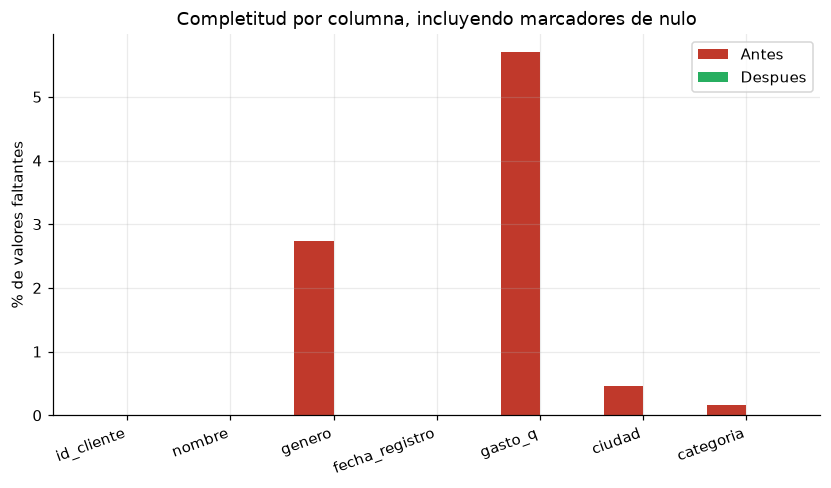

In [14]:
def barras_comparadas(etiquetas, antes, despues, titulo, ylabel, archivo, etiquetar=False):
    x = np.arange(len(etiquetas))
    ancho = .38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    b1 = ax.bar(x - ancho / 2, antes, ancho, label="Antes", color="#c0392b")
    b2 = ax.bar(x + ancho / 2, despues, ancho, label="Despues", color="#27ae60")
    if etiquetar:
        ax.bar_label(b1, padding=2)
        ax.bar_label(b2, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(etiquetas, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    ax.legend()
    fig.savefig(DIR_IMG / archivo, bbox_inches="tight")
    plt.show()

def pct_faltantes(dframe):
    def por_columna(col):
        s = dframe[col].astype("string").str.strip()
        return (s.isna() | s.str.lower().isin(MARCADORES_NULOS)).mean() * 100
    return [por_columna(c) for c in df_original.columns]

barras_comparadas(df_original.columns, pct_faltantes(df_original), pct_faltantes(df),
                  "Completitud por columna, incluyendo marcadores de nulo",
                  "% de valores faltantes", "01_completitud.png")

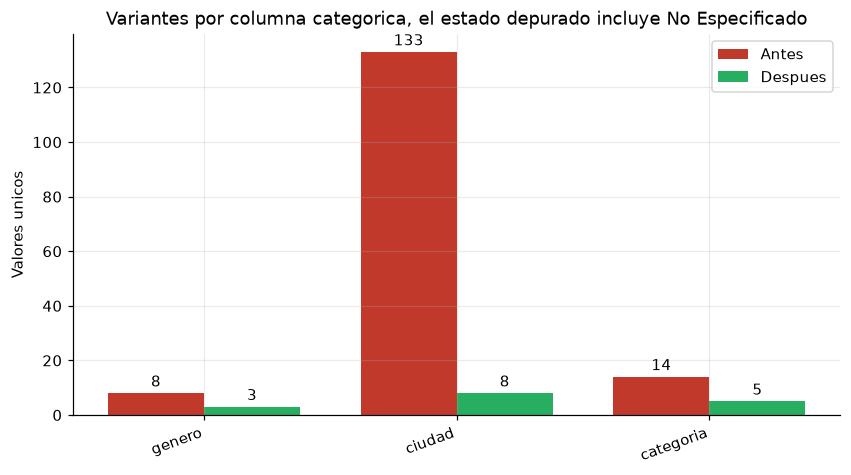

In [15]:
cols_cat = ["genero", "ciudad", "categoria"]
barras_comparadas(cols_cat,
                  [df_original[c].nunique() for c in cols_cat],
                  [df[c].nunique() for c in cols_cat],
                  "Variantes por columna categorica, el estado depurado incluye No Especificado",
                  "Valores unicos", "02_cardinalidad.png", etiquetar=True)

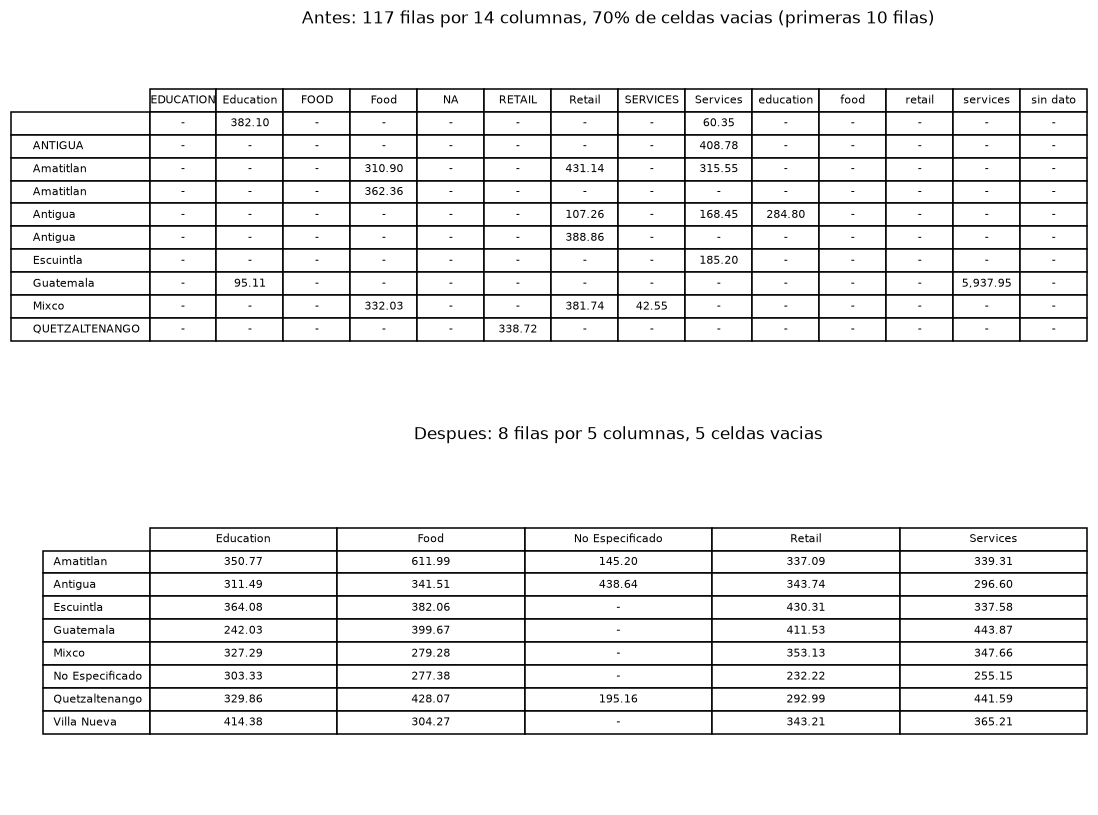

In [16]:
def tabla_png(ax, tabla, titulo):
    ax.axis("off")
    ax.set_title(titulo, fontsize=11, pad=12)
    texto = tabla.map(lambda v: "-" if pd.isna(v) else f"{v:,.2f}")
    t = ax.table(cellText=texto.values, rowLabels=tabla.index, colLabels=tabla.columns,
                 cellLoc="center", loc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(7.5)
    t.scale(1, 1.25)

fig, axes = plt.subplots(2, 1, figsize=(11, 9))
tabla_png(axes[0], pivote_antes.head(10),
          f"Antes: {pivote_antes.shape[0]} filas por {pivote_antes.shape[1]} columnas, "
          f"{vacias_antes / pivote_antes.size * 100:.0f}% de celdas vacias (primeras 10 filas)")
tabla_png(axes[1], pivote_despues,
          f"Despues: {pivote_despues.shape[0]} filas por {pivote_despues.shape[1]} columnas, "
          f"{vacias_despues} celdas vacias")
fig.savefig(DIR_IMG / "03_pivotes.png", bbox_inches="tight")
plt.show()

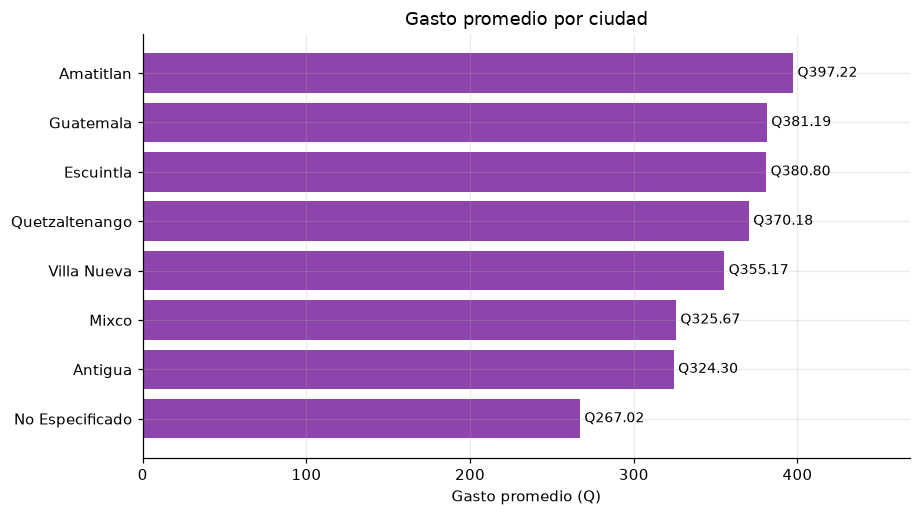

In [17]:
serie = df.groupby("ciudad")["gasto_q"].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(serie.index, serie.values, color="#8e44ad")
ax.bar_label(barras, fmt="Q%.2f", padding=3, fontsize=9)
ax.set_xlabel("Gasto promedio (Q)")
ax.set_xlim(0, serie.max() * 1.18)
ax.set_title("Gasto promedio por ciudad")
fig.savefig(DIR_IMG / "04_gasto_ciudad.png", bbox_inches="tight")
plt.show()

## 6. Exportación

In [18]:
ruta_csv = DIR_SALIDA / "dataset_limpio.csv"
ruta_parquet = DIR_SALIDA / "dataset_limpio.parquet"

df.to_csv(ruta_csv, index=False, encoding="utf-8")
try:
    df.to_parquet(ruta_parquet, index=False)
    print(f"{ruta_parquet} pesa {ruta_parquet.stat().st_size / 1024:.1f} KB")
except Exception as e:
    print("No se generó el parquet, hace falta pyarrow:", e)

print(f"{ruta_csv} pesa {ruta_csv.stat().st_size / 1024:.1f} KB con {len(df):,} registros")
df.head()

data/dataset_limpio.parquet pesa 73.2 KB
data/dataset_limpio.csv pesa 322.4 KB con 4,672 registros


,id_cliente,nombre,genero,fecha_registro,gasto_q,ciudad,categoria,gasto_imputado
0,540080,Ana Mejia,Masculino,2026-01-24,232.41,Villa Nueva,Retail,False
1,579164,Jorge Castillo,Femenino,2026-02-19,251.9,Quetzaltenango,Retail,True
2,529560,Monica Lopez,Femenino,2026-02-27,358.82,Antigua,Education,False
3,518822,Rene Soto,Masculino,2026-01-13,249.89,Quetzaltenango,Retail,False
4,550874,Diego Ramirez,Femenino,2026-01-12,105.8,Amatitlan,Education,False


## 7. Resultados

In [19]:
resumen = pd.Series({
    "Registros": f"{len(df_original):,} -> {len(df):,}",
    "Duplicados eliminados": f"{elim_exactos + elim_id:,}",
    "Montos recuperados": f"{recuperados_coma:,}",
    "Celdas vacias": f"{int(df_original.isna().sum().sum()):,} -> 0",
    "Gasto promedio": f"Q{df['gasto_q'].mean():,.2f}",
    "Gasto mediano": f"Q{df['gasto_q'].median():,.2f}",
    "Gasto total sin imputados": f"Q{total_real:,.2f}",
    "Ciudad con mayor promedio": df.groupby("ciudad")["gasto_q"].mean().idxmax(),
    "Categoria con mas clientes": df["categoria"].value_counts().idxmax(),
})
resumen.to_frame("valor")

,valor
Registros,"5,000 -> 4,672"
Duplicados eliminados,328
Montos recuperados,"2,234"
Celdas vacias,422 -> 0
Gasto promedio,Q361.07
Gasto mediano,Q244.26
Gasto total sin imputados,"Q1,623,416.39"
Ciudad con mayor promedio,Amatitlan
Categoria con mas clientes,Retail


Lo que más pesó fue el separador decimal. Casi la mitad de los montos usaba coma y `to_numeric` los
habría convertido en `NaN` sin lanzar un error, así que el análisis habría corrido completo sobre la
mitad de los datos.

La deduplicación era condición previa para cualquier métrica, porque las filas repetidas inflaban los
conteos por ciudad y categoría. Y la estandarización de texto es lo que vuelve legible la pivote:
para Pandas `quetzaltenango`, `Quetzaltenango` y `  QUETZALTENANGO ` eran tres entidades distintas.

El gasto tiene una distribución asimétrica, con la media bastante por encima de la mediana, lo que
confirma que la mediana era la medida adecuada para imputar.

Queda un hallazgo sin corregir: hay registros donde el género declarado no concuerda con el nombre de
pila. El nombre no es un predictor confiable del género, así que se documenta como un problema de
exactitud a resolver en el sistema de captura y no en el pipeline.